# Test dosing

In [87]:
import math
import pandas as pd
import tellurium as te
import matplotlib.pyplot as plt
import time

bw = 70
age = 30

input_id = 'AGut'
selections = [
    'time', '[AGut]', '[AVen_Plas]', '[AArt_Plas]', '[ALiv]', '[AFat]', '[AKid]', '[AFil]', 'BW', 
]


# Simulate daily oral dosing

Simulate model with daily oral dosing provided as a repetitively triggered event.

In [88]:
def prep_basic(rr_model):
    rr_model.BW = bw

def prep_lt(rr_model):
    rr_model.BWRef = bw
    rr_model.AgeRef = age
    rr_model.Age = age

def prep_fake_lt(rr_model):
    rr_model.setConstant("BW", False)
    rr_model.addParameter("k0", 2, False)
    rr_model.addAssignmentRule("BW", f"{bw} + k0 * (1 + sin(time/300))", False)
    rr_model.regenerateModel(True, True)

models = [
    {
        'id': 'basic',
        'model': '../model/PBK_PFAS.ant',
        'prep_fct': prep_basic
    },
    {
        'id': 'LT',
        'model': '../model/PBK_PFAS_LT.ant',
        'prep_fct': prep_lt
    },
    {
        'id': 'fake_LT',
        'model': '../model/PBK_PFAS.ant',
        'prep_fct': prep_fake_lt
    }
]

def load_parametrisation(model, filename):
    df = pd.read_csv(filename)
    df['Value'] = df['Value'].astype(float)
    for index, row in df.iterrows():
        model[str(row['Parameter'])] = row['Value']

def run_simulation(fn, prep_fct):

    daily_intake = 100
    days_of_exposure = 3 * 365
    days_after_exposure = 1 * 365
    num_days = days_of_exposure + days_after_exposure

    # Load the PBPK model from the SBML file
    rr_model = te.loada(fn)

    # Create a repeating daily oral dosing
    eid = f"oral_daily_exposure"
    rr_model.addEvent(eid, False, f"time % 1 == 0 && time < {days_of_exposure}", False)
    rr_model.addEventAssignment(eid, input_id, f"{input_id} + {daily_intake}", False)
    rr_model.regenerateModel(True, True)

    # Set parameters
    load_parametrisation(rr_model, '../Parametrisations/PFOA_Human.csv')

    # Run model specific prep
    prep_fct(rr_model)

    # Simulate the PBK model
    results = rr_model.simulate(0, num_days, num_days + 1, selections)

    return results

# Run simulations
results = {}
for item in models:
    print(f"Running model {item['model']}...")
    start_time = time.perf_counter()
    results[item['id']] = run_simulation(item['model'], item['prep_fct'])
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f'Task took {elapsed_time:.4f} seconds')


Running model ../model/PBK_PFAS.ant...
Task took 0.4629 seconds
Running model ../model/PBK_PFAS_LT.ant...
Task took 1.8086 seconds
Running model ../model/PBK_PFAS.ant...
Task took 0.7419 seconds


## Report results

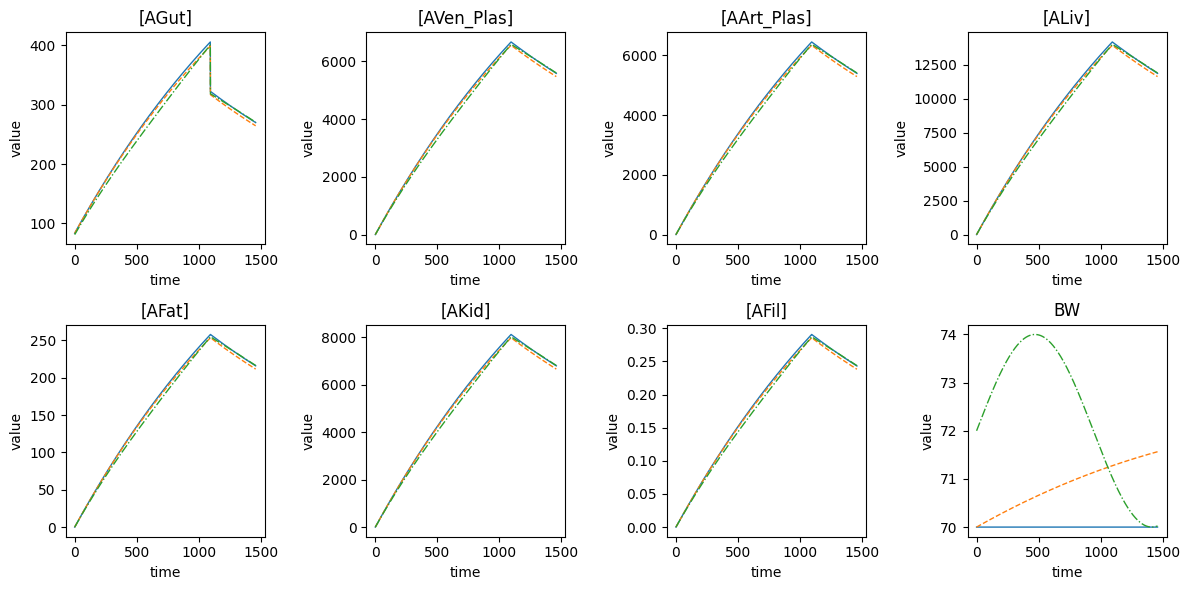

In [89]:
# Plot results
ncols = 4
nrows = math.ceil((len(selections) - 1)/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = axes.flatten()
for ax in axes:
    ax.set(xlabel='time') 
labels = selections
linestyles = ['-', '--', '-.', ':']
for i in range(1, len(selections)):
    sid = selections[i]
    ix = 0
    for key, res in results.items():
        axes[i-1].plot(
            res['time'],
            res[sid],
            linewidth=1,
            linestyle=linestyles[ix % len(linestyles)],
            label=key
        )
        axes[i-1].set(ylabel=f"value", title=labels[i])
        ix = ix + 1
for j in range(len(selections), nrows*ncols + 1):
    fig.delaxes(axes[j-1])
fig.tight_layout()
